# BTC EMA Backtest Review — Gross vs Net Results

**Stage 5.12 — Candle-Level Mark-to-Market Equity Notebook Integration**

Review one fixed BTCUSDT hourly sample, from 2025-10-01 00:00 UTC through
2026-09-30 23:00 UTC. This notebook calls the existing reusable functions:

**Local OHLCV → EMA strategy/execution pipeline → trade ledger → gross and
cost-aware accounting → CLOSED-trade performance summaries → realized-capital
drawdown → candle-level mark-to-market equity → trade duration/exposure →
cost analysis → final OPEN review and conclusions.**

The two accounting functions consume the same ledger independently. Net results
are not calculated by subtracting fees from the separate gross simulation.
Everything is historical research; no orders, real money, or data downloads are used.

## 1. Imports

Use the existing research environment. The project uses a `src/` layout, so add
that directory to the import path. The notebook works when started from the
project root or its `notebooks/` directory. All trading calculations remain in
the imported modules. `hashlib` checks that the local raw CSV stays unchanged.

The existing requests import can emit an urllib3/LibreSSL compatibility warning;
it is not suppressed. Reading the CSV makes no HTTP request.

In [1]:
from pathlib import Path
import hashlib
import sys

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import load_ohlcv_csv
from trading_lab.backtest.pipeline import run_ema_execution_pipeline
from trading_lab.backtest.trades import build_trade_ledger
from trading_lab.backtest.performance import calculate_trade_results
from trading_lab.backtest.costs import calculate_trade_results_with_costs
from trading_lab.analytics.trade_metrics import (
    summarize_gross_trade_performance,
    summarize_net_trade_performance,
)

from trading_lab.analytics.drawdown import (
    calculate_gross_realized_drawdown,
    calculate_net_realized_drawdown,
    summarize_gross_realized_drawdown,
    summarize_net_realized_drawdown,
)

from trading_lab.analytics.equity import (
    calculate_gross_mark_to_market_equity,
    calculate_net_mark_to_market_equity,
)

from trading_lab.analytics.trade_time import (
    calculate_trade_time_breakdown,
    summarize_trade_time_metrics,
)

pd.set_option("display.max_columns", None)

/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Fixed research parameters

Keep EMA20/EMA50 and the 50-candle initialization period exactly as implemented.
No parameter optimization or search takes place here. The long-only spot model
allocates 100% of available capital to one trade at a time, with no leverage.

The net scenario assumes a **0.10% fee per side** and **0.05% adverse slippage
per side**. These are **research assumptions only**, not current Bybit fees.
The cost helper includes the entry fee in sizing, so the entry is self-financing.

In [2]:
FAST_SPAN = 20
SLOW_SPAN = 50
WARMUP_CANDLES = 50
INITIAL_CAPITAL = 10_000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005

START = pd.Timestamp("2025-10-01 00:00", tz="UTC")
END = pd.Timestamp("2026-10-01 00:00", tz="UTC")  # Exclusive.
EXPECTED_CANDLES = 8_760
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"

print(f"EMA spans: {FAST_SPAN}/{SLOW_SPAN}; warm-up: {WARMUP_CANDLES} candles")
print(f"Starting capital: {INITIAL_CAPITAL:,.2f} USDT")
print(f"Research fee: {FEE_RATE:.2%} per side; adverse slippage: {SLIPPAGE_RATE:.2%} per side")

EMA spans: 20/50; warm-up: 50 candles
Starting capital: 10,000.00 USDT
Research fee: 0.10% per side; adverse slippage: 0.05% per side


## 3. Load the existing BTC snapshot

Load and validate the local file with the Stage 1 loader. If it is absent,
stop with a clear error rather than downloading a replacement. The loader
restores UTC timestamps and numeric dtypes and validates the requested hourly
coverage. We do not repeat that validation system or save transformed data.

In [3]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Required local snapshot is missing: {CSV_PATH}")

raw_hash_before = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
candles = load_ohlcv_csv(CSV_PATH, interval="60", start=START, end=END)
candles_before = candles.copy(deep=True)
print("Loaded local snapshot:", CSV_PATH.name)

Loaded local snapshot: BTCUSDT_1h.csv


## 4. Dataset sanity checks

Timestamps label candle **opening** times. Show the dataset size/range, missing
values in the six required OHLCV columns, and duplicate timestamps. Assertions
below are reference checks for this saved sample, not inputs to strategy calculations.

In [4]:
required_columns = ["timestamp", "open", "high", "low", "close", "volume"]
dataset_summary = pd.Series({
    "Candles": len(candles),
    "First timestamp": candles["timestamp"].iloc[0],
    "Last timestamp": candles["timestamp"].iloc[-1],
    "Duplicate timestamps": int(candles["timestamp"].duplicated().sum()),
}, name="Observed")
display(dataset_summary.to_frame())
display(candles[required_columns].isna().sum().rename("Missing values").to_frame())

assert len(candles) == EXPECTED_CANDLES, "Unexpected snapshot row count"
assert candles["timestamp"].iloc[0] == START, "Unexpected first candle"
assert candles["timestamp"].iloc[-1] == END - pd.Timedelta(hours=1), "Unexpected last candle"
display(candles.head(3))

,Observed
Candles,8760
First timestamp,2025-10-01 00:00:00+00:00
Last timestamp,2026-09-30 23:00:00+00:00
Duplicate timestamps,0


,Missing values
timestamp,0
open,0
high,0
low,0
close,0
volume,0


,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905


## 5. Run the strategy/execution pipeline

Stage 4.4 calls the separate EMA strategy and next-open execution helpers.
The first 50 candles initialize the strategy; eligible signals start on candle 51.
This table has one row per candle and contains intent and recorded fill metadata,
but no trade pairing or financial results yet.

In [5]:
pipeline_df = run_ema_execution_pipeline(
    candles, fast_span=FAST_SPAN, slow_span=SLOW_SPAN,
    warmup_candles=WARMUP_CANDLES,
)
pipeline_before = pipeline_df.copy(deep=True)
print("Pipeline shape:", pipeline_df.shape)
print("Pipeline columns:", pipeline_df.columns.tolist())

Pipeline shape: (8760, 14)
Pipeline columns: ['timestamp', 'open', 'close', 'ema_20', 'ema_50', 'warmup_complete', 'bullish_cross', 'bearish_cross', 'signal', 'desired_position', 'signal_time', 'execution_time', 'execution_price', 'executed_position']


## 6. Inspect signals and executions

`desired_position` is intent after a candle completes; `executed_position`
is the position held during that candle. On a signal row N, execution time/price
describe the fill at N+1's OPEN, so the row's own signal does not immediately
change its held position. Signal availability and execution share the same
hourly boundary timestamp, with completion → signal → fill as the causal order.
See [decision 002](../decisions/002_backtest_execution_contract.md).

A signal alone is not proof of a fill: a final-candle event without a next
candle has no execution metadata. Inspect actual executed events below.

In [6]:
entry_count = int(pipeline_df["signal"].eq("LONG_ENTRY").sum())
exit_count = int(pipeline_df["signal"].eq("LONG_EXIT").sum())
final_desired = int(pipeline_df["desired_position"].iloc[-1])
final_executed = int(pipeline_df["executed_position"].iloc[-1])
display(pd.Series({
    "LONG_ENTRY signals": entry_count,
    "LONG_EXIT signals": exit_count,
    "Final desired_position": final_desired,
    "Final executed_position": final_executed,
}, name="Observed").to_frame())

executed_events = pipeline_df.loc[pipeline_df["execution_time"].notna()]
first_entry = executed_events.loc[executed_events["signal"].eq("LONG_ENTRY")].iloc[0]
first_exit = executed_events.loc[executed_events["signal"].eq("LONG_EXIT")].iloc[0]
event_columns = [
    "timestamp", "signal_time", "signal", "execution_time", "execution_price",
    "desired_position", "executed_position",
]
display(pd.DataFrame([first_entry, first_exit])[event_columns])

# Fixed-snapshot references: fail and investigate, never repair the output.
assert (entry_count, exit_count, final_desired, final_executed) == (78, 77, 1, 1)
assert first_entry["execution_time"] == pd.Timestamp("2025-10-13 03:00", tz="UTC")
assert first_exit["execution_time"] == pd.Timestamp("2025-10-14 06:00", tz="UTC")
np.testing.assert_allclose(first_entry["execution_price"], 115_332.3)
np.testing.assert_allclose(first_exit["execution_price"], 112_482.0)

,Observed
LONG_ENTRY signals,78
LONG_EXIT signals,77
Final desired_position,1
Final executed_position,1


,timestamp,signal_time,signal,execution_time,execution_price,desired_position,executed_position
290,2025-10-13 02:00:00+00:00,2025-10-13 03:00:00+00:00,LONG_ENTRY,2025-10-13 03:00:00+00:00,115332.3,1,0
317,2025-10-14 05:00:00+00:00,2025-10-14 06:00:00+00:00,LONG_EXIT,2025-10-14 06:00:00+00:00,112482.0,0,1


## 7. Build the trade ledger

Stage 4.5 pairs **recorded fills**, using their prices and times. Each executed
entry creates one trade. An executed exit makes it CLOSED; an entry with no exit
remains OPEN. The ledger does not invent an exit when the dataset ends.

In [7]:
trades = build_trade_ledger(pipeline_df)
trades_before = trades.copy(deep=True)
closed_count = int(trades["status"].eq("CLOSED").sum())
open_count = int(trades["status"].eq("OPEN").sum())
display(pd.Series({
    "Total trades": len(trades), "CLOSED trades": closed_count, "OPEN trades": open_count,
}, name="Observed").to_frame())
assert (closed_count, open_count) == (77, 1), "Unexpected trade pairing"

,Observed
Total trades,78
CLOSED trades,77
OPEN trades,1


## 8. Inspect first and last trades

One row now represents a trade rather than a candle. `trade_id` starts at 1.
The final row has missing exit time/price because it is still OPEN.
These six recorded ledger columns will remain unchanged in both accounting outputs.

In [8]:
print("First five trades:")
display(trades.head(5))
print("Last five trades:")
display(trades.tail(5))

First five trades:


,trade_id,entry_time,entry_price,exit_time,exit_price,status
0,1,2025-10-13 03:00:00+00:00,115332.3,2025-10-14 06:00:00+00:00,112482.0,CLOSED
1,2,2025-10-19 16:00:00+00:00,108490.4,2025-10-21 10:00:00+00:00,107751.4,CLOSED
2,3,2025-10-21 15:00:00+00:00,112199.9,2025-10-22 04:00:00+00:00,108217.7,CLOSED
3,4,2025-10-23 12:00:00+00:00,109258.6,2025-10-29 01:00:00+00:00,112432.7,CLOSED
4,5,2025-11-01 17:00:00+00:00,110467.3,2025-11-03 02:00:00+00:00,109668.3,CLOSED


Last five trades:


,trade_id,entry_time,entry_price,exit_time,exit_price,status
73,74,2026-09-14 07:00:00+00:00,77597.2,2026-09-15 10:00:00+00:00,76973.0,CLOSED
74,75,2026-09-17 16:00:00+00:00,76786.4,2026-09-23 21:00:00+00:00,84241.8,CLOSED
75,76,2026-09-27 03:00:00+00:00,84452.9,2026-09-28 03:00:00+00:00,83421.4,CLOSED
76,77,2026-09-29 14:00:00+00:00,84206.0,2026-09-29 16:00:00+00:00,83072.2,CLOSED
77,78,2026-09-30 13:00:00+00:00,85293.8,NaT,NaN,OPEN


## 9. Calculate zero-cost gross results

Call Stage 4.6 separately. It sizes each trade using capital available before
entry and compounds the result of each CLOSED trade into the next trade.
The model has zero fees and slippage, and no quantity rounding or leverage.

The compact table shows the first and last three trades. OPEN quantity is known,
but its realized return, PnL, and capital after remain missing. `capital_before`
is capital available **before** the entry, not cash remaining after allocation.

In [9]:
gross_results = calculate_trade_results(trades, initial_capital=INITIAL_CAPITAL)
gross_closed = gross_results.loc[gross_results["status"].eq("CLOSED")].copy()
gross_columns = [
    "trade_id", "entry_time", "exit_time", "status", "capital_before",
    "quantity", "trade_return", "gross_pnl", "capital_after",
]
gross_preview = pd.concat([gross_results.head(3), gross_results.tail(3)])
display(gross_preview[gross_columns].style.format({
    "capital_before": "{:,.6f}", "quantity": "{:.12f}", "trade_return": "{:.4%}",
    "gross_pnl": "{:,.6f}", "capital_after": "{:,.6f}",
}, na_rep="—"))

final_gross_capital = float(gross_closed["capital_after"].iloc[-1])
gross_realized_change = final_gross_capital - INITIAL_CAPITAL
gross_realized_return = gross_realized_change / INITIAL_CAPITAL
print(f"Starting capital: {INITIAL_CAPITAL:,.6f} USDT")
print(f"Final CLOSED-trade gross capital: {final_gross_capital:,.9f} USDT")
print(f"Gross realized change: {gross_realized_change:,.9f} USDT")
print(f"Gross realized return: {gross_realized_return:.6%}")
np.testing.assert_allclose(final_gross_capital, 9_641.111388344, rtol=1e-10)

,trade_id,entry_time,exit_time,status,capital_before,quantity,trade_return,gross_pnl,capital_after
0,1,2025-10-13 03:00:00+00:00,2025-10-14 06:00:00+00:00,CLOSED,"10,000.000000",0.086705979158,-2.4714%,-247.138052,"9,752.861948"
1,2,2025-10-19 16:00:00+00:00,2025-10-21 10:00:00+00:00,CLOSED,"9,752.861948",0.089896082488,-0.6812%,-66.433205,"9,686.428743"
2,3,2025-10-21 15:00:00+00:00,2025-10-22 04:00:00+00:00,CLOSED,"9,686.428743",0.086331883920,-3.5492%,-343.790828,"9,342.637915"
75,76,2026-09-27 03:00:00+00:00,2026-09-28 03:00:00+00:00,CLOSED,"9,893.535569",0.117148559358,-1.2214%,-120.838739,"9,772.696830"
76,77,2026-09-29 14:00:00+00:00,2026-09-29 16:00:00+00:00,CLOSED,"9,772.696830",0.116057012916,-1.3465%,-131.585441,"9,641.111388"
77,78,2026-09-30 13:00:00+00:00,—,OPEN,"9,641.111388",0.113034140680,—,—,—


Starting capital: 10,000.000000 USDT
Final CLOSED-trade gross capital: 9,641.111388344 USDT
Gross realized change: -358.888611656 USDT
Gross realized return: -3.588886%


## 10. Calculate cost-aware net results

Call Stage 4.7 on the same ledger with the fixed research rates. The helper
applies adverse entry/exit slippage, fees on effective notionals, and self-financing
entry sizing. Net capital compounds after CLOSED trades. We inspect existing
columns rather than implement these calculations again.

Two compact views separate sizing/fees from PnL, keeping the tables readable.
Here `gross_pnl` uses the **cost-sized quantity** and recorded prices. It is not
the PnL from the separate Stage 4.6 simulation, whose quantities differ.

In [10]:
net_results = calculate_trade_results_with_costs(
    trades, initial_capital=INITIAL_CAPITAL,
    fee_rate=FEE_RATE, slippage_rate=SLIPPAGE_RATE,
)
net_closed = net_results.loc[net_results["status"].eq("CLOSED")].copy()
net_preview = pd.concat([net_results.head(3), net_results.tail(3)])
sizing_columns = [
    "trade_id", "status", "capital_before", "quantity", "entry_fee", "exit_fee", "total_fees",
]
pnl_columns = [
    "trade_id", "status", "gross_pnl", "price_adjusted_pnl", "net_pnl",
    "net_trade_return", "net_capital_after",
]
display(net_preview[sizing_columns].style.format({
    "capital_before": "{:,.6f}", "quantity": "{:.12f}",
    "entry_fee": "{:,.6f}", "exit_fee": "{:,.6f}", "total_fees": "{:,.6f}",
}, na_rep="—"))
display(net_preview[pnl_columns].style.format({
    "gross_pnl": "{:,.6f}", "price_adjusted_pnl": "{:,.6f}", "net_pnl": "{:,.6f}",
    "net_trade_return": "{:.4%}", "net_capital_after": "{:,.6f}",
}, na_rep="—"))

final_net_capital = float(net_closed["net_capital_after"].iloc[-1])
net_realized_change = final_net_capital - INITIAL_CAPITAL
net_realized_return = net_realized_change / INITIAL_CAPITAL
print(f"Starting capital: {INITIAL_CAPITAL:,.6f} USDT")
print(f"Final CLOSED-trade net capital: {final_net_capital:,.9f} USDT")
print(f"Net realized change: {net_realized_change:,.9f} USDT")
print(f"Net realized return: {net_realized_return:.6%}")
np.testing.assert_allclose(final_net_capital, 7_652.530163437, rtol=1e-10)

,trade_id,status,capital_before,quantity,entry_fee,exit_fee,total_fees
0,1,CLOSED,"10,000.000000",0.086576071762,9.990010,9.733381,19.723391
1,2,CLOSED,"9,723.647198",0.089492514783,9.713933,9.638122,19.352056
2,3,CLOSED,"9,628.484163",0.085686870210,9.618865,9.268200,18.887065
75,76,CLOSED,"7,900.148168",0.093404865389,7.892256,7.788069,15.680325
76,77,CLOSED,"7,780.280587",0.092257366062,7.772508,7.660190,15.432698
77,78,OPEN,"7,652.530163",0.089585230647,7.644885,—,—


,trade_id,status,gross_pnl,price_adjusted_pnl,net_pnl,net_trade_return,net_capital_after
0,1,CLOSED,-246.767777,-256.629411,-276.352802,-2.7635%,"9,723.647198"
1,2,CLOSED,-66.134968,-75.810980,-95.163035,-0.9787%,"9,628.484163"
2,3,CLOSED,-341.222255,-350.665702,-369.552767,-3.8381%,"9,258.931397"
75,76,CLOSED,-96.347119,-104.187257,-119.867581,-1.5173%,"7,780.280587"
76,77,CLOSED,-104.601402,-112.317725,-127.750423,-1.6420%,"7,652.530163"
77,78,OPEN,—,—,—,—,—


Starting capital: 10,000.000000 USDT
Final CLOSED-trade net capital: 7,652.530163437 USDT
Net realized change: -2,347.469836563 USDT
Net realized return: -23.474698%


## 11. Compare gross vs net

Compare both independently compounded simulations from the same starting
capital and recorded trades. Realized return here means change from starting
capital divided by starting capital; it is not annualized or a sum of trade returns.

The final-capital difference includes **fees, slippage, and their compounded
impact on later position sizing**. It is not simply the sum of fees. These are
values after the last CLOSED trade and before the final OPEN entry, not portfolio
ending values.

In [11]:
comparison = pd.DataFrame({
    "Gross": [INITIAL_CAPITAL, final_gross_capital, gross_realized_change, gross_realized_return],
    "Net": [INITIAL_CAPITAL, final_net_capital, net_realized_change, net_realized_return],
}, index=["Starting capital (USDT)", "Final realized capital (USDT)",
          "Realized change (USDT)", "Realized return"])
comparison.index.name = "Metric"
display(comparison.style.format("{:,.6f}").format("{:.6%}", subset=pd.IndexSlice[["Realized return"], :]))

capital_difference = final_gross_capital - final_net_capital
print(f"Gross minus net final realized capital: {capital_difference:,.9f} USDT")
np.testing.assert_allclose(capital_difference, 1_988.581224907, rtol=1e-10)

,Gross,Net
Metric,,
Starting capital (USDT),"10,000.000000","10,000.000000"
Final realized capital (USDT),"9,641.111388","7,652.530163"
Realized change (USDT),-358.888612,"-2,347.469837"
Realized return,-3.588886%,-23.474698%


Gross minus net final realized capital: 1,988.581224907 USDT


## 12. Plot realized capital by completed trade

Trade 0 is the starting capital before the first entry. Each later point is
capital after a CLOSED trade. The lines connect these observations for readability;
the horizontal axis is completed trade number, not elapsed time.

This is **trade-by-trade realized capital**, not a candle-level portfolio equity
curve. OPEN positions and within-trade price movements are not valued by this
plot. The separate candle-level MTM plot below keeps those observations; both
views remain useful and neither replaces the other.

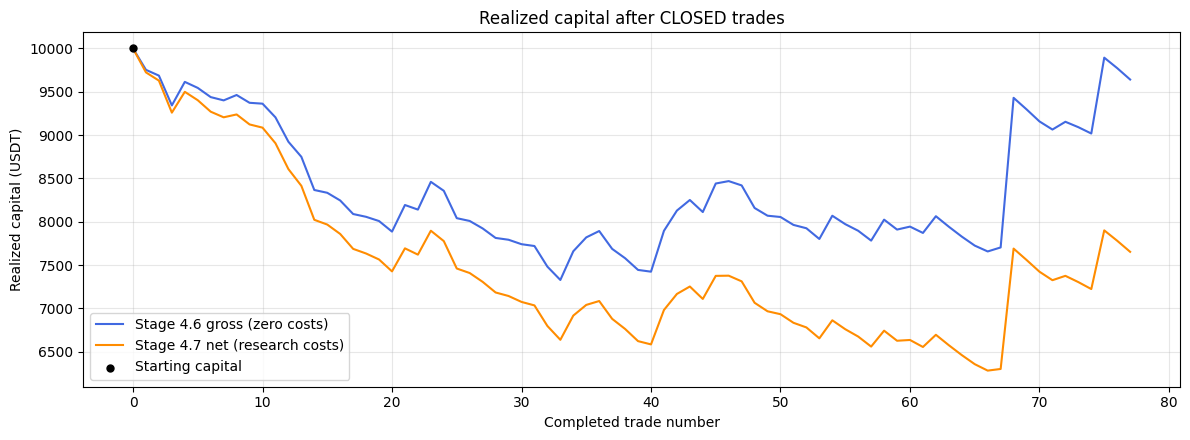

In [12]:
pd.testing.assert_series_equal(gross_closed["trade_id"], net_closed["trade_id"])
completed_trade_numbers = [0, *gross_closed["trade_id"].tolist()]
gross_capital_points = [INITIAL_CAPITAL, *gross_closed["capital_after"].tolist()]
net_capital_points = [INITIAL_CAPITAL, *net_closed["net_capital_after"].tolist()]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(completed_trade_numbers, gross_capital_points, label="Stage 4.6 gross (zero costs)", color="royalblue")
ax.plot(completed_trade_numbers, net_capital_points, label="Stage 4.7 net (research costs)", color="darkorange")
ax.scatter([0], [INITIAL_CAPITAL], color="black", s=25, zorder=4, label="Starting capital")
ax.set(title="Realized capital after CLOSED trades", xlabel="Completed trade number", ylabel="Realized capital (USDT)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 13. CLOSED-trade performance summary

Call the Stage 5.2 analytics functions on the **existing** `gross_results`
and `net_results`. [Decision 003](../decisions/003_closed_trade_performance_metrics.md)
defines the 16 metrics; their formulas stay in the reusable module.
GROSS uses Stage 4.6 zero-cost returns/PnL. NET uses Stage 4.7 net
returns/PnL, with its own cost-aware sizing and compounding.

Only CLOSED trades enter this table. The final OPEN trade contributes
nothing to counts, rates, averages, expectancy, or profit factor and is not
valued by this CLOSED-only summary. The separate MTM section below values it. Percentages, USDT amounts, and rounded ratios below are **display
formatting only**; the summaries retain their full-precision values.

In [13]:
gross_before_metrics = gross_results.copy(deep=True)
net_before_metrics = net_results.copy(deep=True)
gross_summary = summarize_gross_trade_performance(gross_results)
net_summary = summarize_net_trade_performance(net_results)

metric_labels = {
    "closed_trade_count": "CLOSED trades",
    "winning_trade_count": "Winning trades",
    "losing_trade_count": "Losing trades",
    "breakeven_trade_count": "Breakeven trades",
    "win_rate": "Win rate",
    "loss_rate": "Loss rate",
    "breakeven_rate": "Breakeven rate",
    "average_trade_return": "Average trade return",
    "median_trade_return": "Median trade return",
    "average_win_return": "Average winning return",
    "average_loss_return": "Average losing return",
    "best_trade_return": "Best trade return",
    "worst_trade_return": "Worst trade return",
    "total_realized_pnl": "Total realized PnL",
    "expectancy_pnl": "Sample expectancy per CLOSED trade",
    "profit_factor": "Profit factor",
}
performance_table = pd.concat([gross_summary, net_summary]).T.rename(
    index=metric_labels, columns={"GROSS": "Gross", "NET": "Net"},
)
performance_table.index.name = "Metric"
display(performance_table.style.format("{:.6f}", na_rep="—")
    .format("{:,.0f}", subset=pd.IndexSlice[list(metric_labels.values())[:4], :])
    .format("{:.6%}", subset=pd.IndexSlice[list(metric_labels.values())[4:13], :])
    .format("{:,.6f} USDT", subset=pd.IndexSlice[list(metric_labels.values())[13:15], :]))

,Gross,Net
Metric,,
CLOSED trades,77,77
Winning trades,20,20
Losing trades,57,57
Breakeven trades,0,0
Win rate,25.974026%,25.974026%
Loss rate,74.025974%,74.025974%
Breakeven rate,0.000000%,0.000000%
Average trade return,0.007059%,-0.292513%
Median trade return,-0.873529%,-1.170463%


## 14. Read the metrics and compare gross vs net

**WIN / LOSS / BREAKEVEN** use each path's unrounded trade return:
above +`1e-12` is WIN, below -`1e-12` is LOSS, and inside or on those
boundaries is BREAKEVEN. Formatting a tiny return as 0% does not change
its classification. **Win rate** is the share of CLOSED trades classed WIN.
A low win rate can still work if winners are sufficiently larger than
losers; it does not establish profitability on its own.

**Average trade return** is the arithmetic mean across CLOSED trades,
including breakevens. **Average winning/losing return** uses only that
path's WIN/LOSS subset. Returns normalize trades for comparison and
determine classification. PnL records realized USDT on the capital actually
allocated, and supplies total PnL, expectancy, and profit factor.

**Sample expectancy** is historical average realized PnL per CLOSED trade.
It describes this sample; it is not a prediction, a probability forecast,
or guaranteed future profit/loss. **Profit factor** compares the sum of
WIN PnL with the absolute sum of LOSS PnL: above 1 means winning PnL
exceeds losing PnL, 1 means equal, and below 1 means losses exceed wins.
Breakeven residuals remain in totals/expectancy but not these two aggregates.

Arithmetic average return and compounded strategy return describe different
things. Capital follows the sequence of trades: each return acts on capital
left by previous trades, rather than on the same starting amount. Losses and
gains do not cancel arithmetically; a loss leaves less capital for the next
trade. Compounding can therefore finish below the starting capital despite
a slightly positive arithmetic average. In this full-allocation, fixed-rate
model, reordering the same returns would not change their final product.

In [14]:
gross_metrics = gross_summary.loc["GROSS"]
net_metrics = net_summary.loc["NET"]
display(Markdown(
    f"**This BTC sample:** both paths have **{int(gross_metrics['winning_trade_count'])} "
    f"wins / {int(gross_metrics['closed_trade_count'])} CLOSED trades**, a win rate of "
    f"**{gross_metrics['win_rate']:.2%}**, with **{int(gross_metrics['losing_trade_count'])} "
    f"losses** and **{int(gross_metrics['breakeven_trade_count'])} breakevens**. "
    "Costs happened to leave classification unchanged here; another sample could "
    "turn a gross WIN into a net LOSS.\n\n"
    f"Average winning return falls from **{gross_metrics['average_win_return']:+.2%}** "
    f"gross to **{net_metrics['average_win_return']:+.2%}** net; average losing return "
    f"worsens from **{gross_metrics['average_loss_return']:+.2%}** to "
    f"**{net_metrics['average_loss_return']:+.2%}**. Average trade return falls from "
    f"**{gross_metrics['average_trade_return']:+.6%}** to "
    f"**{net_metrics['average_trade_return']:+.6%}**.\n\n"
    f"Profit factor falls from **{gross_metrics['profit_factor']:.3f}** to "
    f"**{net_metrics['profit_factor']:.3f}**. Both are below 1: winning PnL did not "
    "fully compensate for losing PnL in this sample. Total realized PnL is "
    f"**{gross_metrics['total_realized_pnl']:,.2f} USDT** gross and "
    f"**{net_metrics['total_realized_pnl']:,.2f} USDT** net. Sample expectancy worsens "
    f"from **{gross_metrics['expectancy_pnl']:,.2f} USDT** to "
    f"**{net_metrics['expectancy_pnl']:,.2f} USDT per CLOSED trade**.\n\n"
    f"The gross arithmetic average is slightly positive "
    f"(**{gross_metrics['average_trade_return']:+.6%}**), yet gross realized capital "
    f"ends at **{final_gross_capital:,.2f} USDT**, below **{INITIAL_CAPITAL:,.2f} USDT**. "
    f"After modeled costs, final realized capital falls further to "
    f"**{final_net_capital:,.2f} USDT**. These observations describe this historical "
    "sample under the stated assumptions; they do not establish general strategy quality."
))

**This BTC sample:** both paths have **20 wins / 77 CLOSED trades**, a win rate of **25.97%**, with **57 losses** and **0 breakevens**. Costs happened to leave classification unchanged here; another sample could turn a gross WIN into a net LOSS.

Average winning return falls from **+3.87%** gross to **+3.55%** net; average losing return worsens from **-1.35%** to **-1.64%**. Average trade return falls from **+0.007059%** to **-0.292513%**.

Profit factor falls from **0.945** to **0.675**. Both are below 1: winning PnL did not fully compensate for losing PnL in this sample. Total realized PnL is **-358.89 USDT** gross and **-2,347.47 USDT** net. Sample expectancy worsens from **-4.66 USDT** to **-30.49 USDT per CLOSED trade**.

The gross arithmetic average is slightly positive (**+0.007059%**), yet gross realized capital ends at **9,641.11 USDT**, below **10,000.00 USDT**. After modeled costs, final realized capital falls further to **7,652.53 USDT**. These observations describe this historical sample under the stated assumptions; they do not establish general strategy quality.

## 15. Check summary regressions and OPEN exclusion

The fixed references below validate this saved BTC sample; they never supply
calculation outputs. A mismatch stops execution for investigation. Compare
each summary with the same helper called on its existing CLOSED-only view:
removing the final OPEN row must leave **all 16 metrics identical**.
Also confirm analytics did not change either accounting input.

In [15]:
count_columns = [
    "closed_trade_count", "winning_trade_count", "losing_trade_count", "breakeven_trade_count",
]
for summary, label in [(gross_summary, "GROSS"), (net_summary, "NET")]:
    assert tuple(summary.loc[label, count_columns]) == (77, 20, 57, 0)

reference_columns = [
    "win_rate", "loss_rate", "breakeven_rate", "average_trade_return", "median_trade_return",
    "average_win_return", "average_loss_return", "best_trade_return", "worst_trade_return",
    "total_realized_pnl", "expectancy_pnl", "profit_factor",
]
gross_reference = [
    .259740259740, .740259740260, 0.0, .000070588288, -.008735290732,
    .038651616726, -.013466614673, .224171061391, -.043755772679,
    -358.888611656, -4.660891060, .945165760246,
]
net_reference = [
    .259740259740, .740259740260, 0.0, -.002925128404, -.011704629367,
    .035540330361, -.016421780603, .220504050556, -.046620207277,
    -2347.469836563, -30.486621254, .675088667158,
]
np.testing.assert_allclose(gross_summary.loc["GROSS", reference_columns], gross_reference, rtol=1e-10, atol=1e-9)
np.testing.assert_allclose(net_summary.loc["NET", reference_columns], net_reference, rtol=1e-10, atol=1e-9)

assert gross_results["status"].iloc[-1] == net_results["status"].iloc[-1] == "OPEN"
pd.testing.assert_frame_equal(gross_summary, summarize_gross_trade_performance(gross_closed))
pd.testing.assert_frame_equal(net_summary, summarize_net_trade_performance(net_closed))
pd.testing.assert_frame_equal(gross_results, gross_before_metrics)
pd.testing.assert_frame_equal(net_results, net_before_metrics)
print("All 16 gross/net references passed; OPEN exclusion and accounting-input preservation passed.")

All 16 gross/net references passed; OPEN exclusion and accounting-input preservation passed.


## 16. REALIZED-CAPITAL DRAWDOWN

Use all four existing Stage 5.5 helpers from
`trading_lab.analytics.drawdown` on the existing accounting outputs, with the
same `INITIAL_CAPITAL`. [Decision 004](../decisions/004_realized_capital_drawdown.md)
defines this separate path-dependent component. The 16-metric table above stays
unchanged; no accounting, peaks, or drawdown formulas are rebuilt here.

**Why 78 observations for 77 CLOSED trades?** Observation 0 is initial capital,
then observations 1–77 are capital after each CLOSED trade in existing order.
Including the initial point measures a first-trade loss against starting capital.
The final OPEN trade adds no observation: there are 78 rows, not 79.

> **REALIZED-CAPITAL only — mark-to-market drawdown may be worse.**
> This path observes only initial capital and capital after CLOSED trades.
> It does not observe unrealized PnL while a trade is open, intratrade adverse
> movement, candle-by-candle portfolio equity, or the final OPEN position's
> market value. These realized paths leave it unvalued; the separate MTM
> section below marks OPEN positions without changing realized analytics.

The table reads directly from the helper outputs. The trough is the earliest
observation matching the summary's maximum percentage decline. Its USDT amount
belongs to that same point; it need not be the largest currency decline elsewhere.
Formatting changes presentation only, preserving the full-precision source values.

In [16]:
gross_before_drawdown = gross_results.copy(deep=True)
net_before_drawdown = net_results.copy(deep=True)

gross_drawdown_path = calculate_gross_realized_drawdown(
    gross_results, initial_capital=INITIAL_CAPITAL,
)
net_drawdown_path = calculate_net_realized_drawdown(
    net_results, initial_capital=INITIAL_CAPITAL,
)
gross_drawdown_summary = summarize_gross_realized_drawdown(
    gross_results, initial_capital=INITIAL_CAPITAL,
)
net_drawdown_summary = summarize_net_realized_drawdown(
    net_results, initial_capital=INITIAL_CAPITAL,
)

# Locate the earliest point selected by each summary; do not recalculate maxima.
gross_drawdown_trough = gross_drawdown_path.loc[
    gross_drawdown_path["drawdown"].eq(gross_drawdown_summary.loc["GROSS", "max_realized_drawdown"])
].iloc[0]
net_drawdown_trough = net_drawdown_path.loc[
    net_drawdown_path["drawdown"].eq(net_drawdown_summary.loc["NET", "max_realized_drawdown"])
].iloc[0]

drawdown_labels = [
    "CLOSED trades", "Drawdown observations (including initial)",
    "Maximum realized-capital drawdown", "Amount at maximum realized-capital drawdown",
    "Trough observation", "Trough CLOSED-trade number", "Capital at trough",
    "Running peak at trough", "Final realized capital",
]
drawdown_table = pd.DataFrame({
    label: [
        closed_count, len(drawdown_path),
        drawdown_summary.loc[source, "max_realized_drawdown"],
        drawdown_summary.loc[source, "max_realized_drawdown_amount"],
        int(trough["observation"]), int(trough["closed_trade_number"]),
        trough["capital"], trough["running_peak"], drawdown_path["capital"].iloc[-1],
    ]
    for label, source, drawdown_path, drawdown_summary, trough in [
        ("Gross", "GROSS", gross_drawdown_path, gross_drawdown_summary, gross_drawdown_trough),
        ("Net", "NET", net_drawdown_path, net_drawdown_summary, net_drawdown_trough),
    ]
}, index=drawdown_labels)
drawdown_table.index.name = "Realized-capital result"
display(drawdown_table.style.format("{:,.6f} USDT")
    .format("{:,.0f}", subset=pd.IndexSlice[drawdown_labels[:2] + drawdown_labels[4:6], :])
    .format("{:.6%}", subset=pd.IndexSlice[[drawdown_labels[2]], :]))

,Gross,Net
Realized-capital result,,
CLOSED trades,77,77
Drawdown observations (including initial),78,78
Maximum realized-capital drawdown,-26.723425%,-37.185533%
Amount at maximum realized-capital drawdown,"-2,672.342545 USDT","-3,718.553326 USDT"
Trough observation,33,66
Trough CLOSED-trade number,33,66
Capital at trough,"7,327.657455 USDT","6,281.446674 USDT"
Running peak at trough,"10,000.000000 USDT","10,000.000000 USDT"
Final realized capital,"9,641.111388 USDT","7,652.530163 USDT"


## 17. Read the realized-capital drawdowns

Each percentage describes how far below the previous **observed realized-capital
peak** the account was after a CLOSED trade. A later recovery changes the ending
capital but does not erase the earlier maximum decline. These troughs are not the
lowest market values of the portfolio while positions were open.

Costs affect compounded quantities and capital, so gross and net can have different
trough locations, peak levels, and drawdown percentages. NET drawdown is not simply
GROSS drawdown minus costs. The explanation below uses the calculated outputs.

For illustration only: capital starts at 10,000 USDT, a position temporarily has
market value 7,000, then closes at 9,500. The realized-capital observations see
about −5%; a mark-to-market path including the temporary value could see −30%.
This is a hypothetical illustration, not a BTC result. The separate MTM
section implements CLOSE valuations, but portfolio drawdown is not calculated.

In [17]:
display(Markdown(
    f"**GROSS:** maximum realized-capital drawdown is "
    f"**{gross_drawdown_summary.loc['GROSS', 'max_realized_drawdown']:.2%}**. "
    f"At observation / CLOSED trade **{int(gross_drawdown_trough['observation'])}**, "
    f"realized capital was **{gross_drawdown_trough['capital']:,.2f} USDT**, below "
    f"its previous observed peak of **{gross_drawdown_trough['running_peak']:,.2f} USDT**. "
    f"The path later recovered part of that decline and ended at "
    f"**{gross_drawdown_path['capital'].iloc[-1]:,.2f} USDT**.\n\n"
    f"**NET:** maximum realized-capital drawdown is "
    f"**{net_drawdown_summary.loc['NET', 'max_realized_drawdown']:.2%}**. "
    f"Its trough occurs later in this sample, at observation / CLOSED trade "
    f"**{int(net_drawdown_trough['observation'])}**, with capital "
    f"**{net_drawdown_trough['capital']:,.2f} USDT** and previous observed peak "
    f"**{net_drawdown_trough['running_peak']:,.2f} USDT**. It ended at "
    f"**{net_drawdown_path['capital'].iloc[-1]:,.2f} USDT** under the stated research "
    "cost assumptions. These are CLOSED-trade realized-capital observations, "
    "not mark-to-market portfolio drawdowns."
))

**GROSS:** maximum realized-capital drawdown is **-26.72%**. At observation / CLOSED trade **33**, realized capital was **7,327.66 USDT**, below its previous observed peak of **10,000.00 USDT**. The path later recovered part of that decline and ended at **9,641.11 USDT**.

**NET:** maximum realized-capital drawdown is **-37.19%**. Its trough occurs later in this sample, at observation / CLOSED trade **66**, with capital **6,281.45 USDT** and previous observed peak **10,000.00 USDT**. It ended at **7,652.53 USDT** under the stated research cost assumptions. These are CLOSED-trade realized-capital observations, not mark-to-market portfolio drawdowns.

## 18. Plot REALIZED-CAPITAL drawdown

How far below the previous realized-capital peak were we after each CLOSED trade?
Plot the helper's `drawdown` against its `closed_trade_number`, including observation
0. The markers use the derived trough rows above, not hardcoded trade numbers.
The x-axis counts completed trades; it is not a candle axis or continuous time.

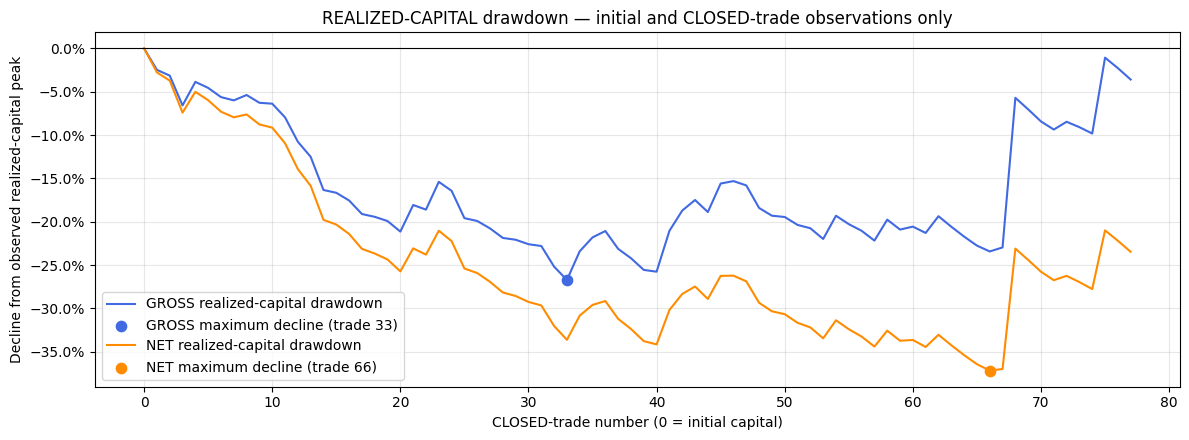

In [18]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for label, drawdown_path, trough, color in [
    ("GROSS", gross_drawdown_path, gross_drawdown_trough, "royalblue"),
    ("NET", net_drawdown_path, net_drawdown_trough, "darkorange"),
]:
    ax.plot(
        drawdown_path["closed_trade_number"], drawdown_path["drawdown"],
        label=f"{label} realized-capital drawdown", color=color,
    )
    ax.scatter(
        int(trough["closed_trade_number"]), trough["drawdown"],
        color=color, s=55, zorder=4,
        label=f"{label} maximum decline (trade {int(trough['closed_trade_number'])})",
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set(
    title="REALIZED-CAPITAL drawdown — initial and CLOSED-trade observations only",
    xlabel="CLOSED-trade number (0 = initial capital)",
    ylabel="Decline from observed realized-capital peak",
)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 19. Check drawdown references and OPEN exclusion

These BTC references validate the helper outputs; they never supply table or plot
values. A mismatch stops execution for investigation. Check initial capital,
78 observations for 77 CLOSED trades, the troughs, and final CLOSED capital.
No drawdown formulas are duplicated in these assertions.

Remove the final OPEN row and call the same four helpers again: both paths and
both summaries must remain identical. Confirm that analytics and presentation
preserved both accounting inputs.

In [19]:
assert closed_count == 77
assert len(gross_drawdown_path) == len(net_drawdown_path) == 78
assert gross_results["status"].iloc[-1] == net_results["status"].iloc[-1] == "OPEN"
for drawdown_path, closed_results, capital_column in [
    (gross_drawdown_path, gross_closed, "capital_after"),
    (net_drawdown_path, net_closed, "net_capital_after"),
]:
    assert len(drawdown_path) == len(closed_results) + 1
    assert drawdown_path.loc[0, "observation"] == drawdown_path.loc[0, "closed_trade_number"] == 0
    assert drawdown_path.loc[0, "capital"] == drawdown_path.loc[0, "running_peak"] == INITIAL_CAPITAL
    assert drawdown_path.loc[0, "drawdown"] == drawdown_path.loc[0, "drawdown_amount"] == 0.0
    np.testing.assert_allclose(drawdown_path["capital"].iloc[-1], closed_results[capital_column].iloc[-1])

for source, drawdown_path, drawdown_summary, trough, observation, references in [
    ("GROSS", gross_drawdown_path, gross_drawdown_summary, gross_drawdown_trough, 33,
     [-.267234254550, -2672.342545499, 7327.657454501, 10000.0, 9641.111388344]),
    ("NET", net_drawdown_path, net_drawdown_summary, net_drawdown_trough, 66,
     [-.371855332627, -3718.553326267, 6281.446673733, 10000.0, 7652.530163437]),
]:
    assert int(trough["observation"]) == int(trough["closed_trade_number"]) == observation
    np.testing.assert_allclose([
        drawdown_summary.loc[source, "max_realized_drawdown"],
        drawdown_summary.loc[source, "max_realized_drawdown_amount"],
        trough["capital"], trough["running_peak"], drawdown_path["capital"].iloc[-1],
    ], references, rtol=1e-10, atol=1e-9)

pd.testing.assert_frame_equal(gross_drawdown_path, calculate_gross_realized_drawdown(
    gross_results.iloc[:-1], initial_capital=INITIAL_CAPITAL,
))
pd.testing.assert_frame_equal(net_drawdown_path, calculate_net_realized_drawdown(
    net_results.iloc[:-1], initial_capital=INITIAL_CAPITAL,
))
pd.testing.assert_frame_equal(gross_drawdown_summary, summarize_gross_realized_drawdown(
    gross_results.iloc[:-1], initial_capital=INITIAL_CAPITAL,
))
pd.testing.assert_frame_equal(net_drawdown_summary, summarize_net_realized_drawdown(
    net_results.iloc[:-1], initial_capital=INITIAL_CAPITAL,
))
pd.testing.assert_frame_equal(gross_results, gross_before_drawdown)
pd.testing.assert_frame_equal(net_results, net_before_drawdown)
print("Drawdown references, 78-point paths, OPEN exclusion, and accounting-input preservation passed.")

Drawdown references, 78-point paths, OPEN exclusion, and accounting-input preservation passed.


## 20. CANDLE-LEVEL MARK-TO-MARKET EQUITY

Call the two unchanged Stage 5.11 helpers from `trading_lab.analytics.equity`
on the existing `candles`, `gross_results`, and `net_results`, with the same
`INITIAL_CAPITAL` and an explicit one-hour interval. All equity calculations
stay in the reusable module; the notebook only inspects, formats, plots, and
checks its outputs.

**Realized capital** observes initial capital plus capital after CLOSED trades.
**Mark-to-market (MTM) equity** observes initial capital plus portfolio value
after **every candle CLOSE**, including while a position is OPEN. For a purely
conceptual example, realized capital might show 10,000 → 9,500 while MTM shows
10,000 → 9,800 → 8,900 → 9,200 → 9,500. The intermediate decline is visible only
in the latter. This example supplies no calculations or BTC metrics.

**8,760 candles → 8,761 observations.** Observation 0 is flat immediately before
any first-OPEN fill, with initial cash/equity and an undefined mark. Each later
row values the completed candle at its raw CLOSE and is timed at OPEN + interval.
Actual fills at that OPEN occur before its CLOSE mark: EXIT then ENTRY if both
share an OPEN. A previous CLOSE row precedes next-OPEN fills at the same timestamp.

GROSS and NET are **independent simulations**, not GROSS minus cumulative costs.
Both use the same raw CLOSE marks; differences come from canonical quantity
sizing, entry slippage/paid fees, actual exits, and realized capital compounding.
NET includes costs already incurred, without charging the entry fee twice or
hypothetical future exit fees/sell slippage. Marking is valuation, not liquidation.


In [20]:
candles_before_equity = candles.copy(deep=True)
gross_before_equity = gross_results.copy(deep=True)
net_before_equity = net_results.copy(deep=True)
candle_interval = pd.Timedelta(hours=1)

gross_equity_path = calculate_gross_mark_to_market_equity(
    candles, gross_results, candle_interval, initial_capital=INITIAL_CAPITAL,
)
net_equity_path = calculate_net_mark_to_market_equity(
    candles, net_results, candle_interval, initial_capital=INITIAL_CAPITAL,
)
pd.testing.assert_frame_equal(candles, candles_before_equity)
pd.testing.assert_frame_equal(gross_results, gross_before_equity)
pd.testing.assert_frame_equal(net_results, net_before_equity)
gross_equity_before_display = gross_equity_path.copy(deep=True)
net_equity_before_display = net_equity_path.copy(deep=True)
print(f"{len(candles):,} candles → {len(gross_equity_path):,} GROSS / {len(net_equity_path):,} NET observations")


8,760 candles → 8,761 GROSS / 8,761 NET observations


## 21. Inspect compact equity-path previews

Show observation 0, three candle-close rows around the first recorded entry,
and the final three rows for each independent path. The first-entry boundary's
preceding CLOSE is still flat; its first held CLOSE mark is one hour later.
Each displayed row retains its original observation index. A dash means a
missing mark/active ID, not a zero market price. Formatting does not change
helper outputs; no full 8,761-row table is displayed.


In [21]:
first_equity_entry = trades["entry_time"].iloc[0]
equity_preview_columns = [
    "valuation_time", "mark_price", "position", "active_trade_id", "cash",
    "quantity", "unrealized_pnl", "equity",
]
equity_preview_formats = {
    "valuation_time": lambda value: value.strftime("%Y-%m-%d %H:%M %Z"),
    "mark_price": "{:,.2f}", "position": "{:,.0f}", "active_trade_id": "{:,.0f}",
    "cash": "{:,.6f}", "quantity": "{:.12f}",
    "unrealized_pnl": "{:,.6f}", "equity": "{:,.6f}",
}
for label, equity_path in [("GROSS", gross_equity_path), ("NET", net_equity_path)]:
    around_first_entry = equity_path.loc[
        equity_path["candle_timestamp"].between(
            first_equity_entry - candle_interval, first_equity_entry + candle_interval,
        )
    ]
    equity_preview = pd.concat([equity_path.head(1), around_first_entry, equity_path.tail(3)])
    print(label, "— initial, first-entry neighborhood, and final CLOSE observations")
    display(equity_preview[equity_preview_columns].style.format(equity_preview_formats, na_rep="—"))


GROSS — initial, first-entry neighborhood, and final CLOSE observations


,valuation_time,mark_price,position,active_trade_id,cash,quantity,unrealized_pnl,equity
0,2025-10-01 00:00 UTC,—,0,—,"10,000.000000",0.000000000000,0.000000,"10,000.000000"
291,2025-10-13 03:00 UTC,"115,332.30",0,—,"10,000.000000",0.000000000000,0.000000,"10,000.000000"
292,2025-10-13 04:00 UTC,"114,840.00",1,1,0.000000,0.086705979158,-42.685354,"9,957.314646"
293,2025-10-13 05:00 UTC,"114,714.30",1,1,0.000000,0.086705979158,-53.584295,"9,946.415705"
8758,2026-09-30 22:00 UTC,"83,758.60",1,78,0.000000,0.113034140680,-173.530013,"9,467.581376"
8759,2026-09-30 23:00 UTC,"83,683.20",1,78,0.000000,0.113034140680,-182.052787,"9,459.058601"
8760,2026-10-01 00:00 UTC,"83,616.20",1,78,0.000000,0.113034140680,-189.626074,"9,451.485314"


NET — initial, first-entry neighborhood, and final CLOSE observations


,valuation_time,mark_price,position,active_trade_id,cash,quantity,unrealized_pnl,equity
0,2025-10-01 00:00 UTC,—,0,—,"10,000.000000",0.000000000000,0.000000,"10,000.000000"
291,2025-10-13 03:00 UTC,"115,332.30",0,—,"10,000.000000",0.000000000000,0.000000,"10,000.000000"
292,2025-10-13 04:00 UTC,"114,840.00",1,1,0.000000,0.086576071762,-47.613909,"9,942.396081"
293,2025-10-13 05:00 UTC,"114,714.30",1,1,0.000000,0.086576071762,-58.496521,"9,931.513469"
8758,2026-09-30 22:00 UTC,"83,758.60",1,78,0.000000,0.089585230647,-141.351778,"7,503.533500"
8759,2026-09-30 23:00 UTC,"83,683.20",1,78,0.000000,0.089585230647,-148.106505,"7,496.778773"
8760,2026-10-01 00:00 UTC,"83,616.20",1,78,0.000000,0.089585230647,-154.108715,"7,490.776563"


## 22. Compare last realized capital with final marked equity

The first column is canonical capital after the last CLOSED trade, before the
final OPEN entry. The second comes directly from the final equity-path row.
These differ because trade 78 remains OPEN and its market price moved after
entry; NET also reflects the entry costs already incurred. Its marked value
is **not realized ending capital**. No exit is invented and no future exit
costs are charged. Detailed final OPEN state is inspected later below.


In [22]:
final_gross_mark = gross_equity_path.iloc[-1]
final_net_mark = net_equity_path.iloc[-1]
realized_vs_marked = pd.DataFrame({
    "Last realized CLOSED capital": [final_gross_capital, final_net_capital],
    "Final marked equity": [final_gross_mark["equity"], final_net_mark["equity"]],
}, index=["GROSS", "NET"])
realized_vs_marked.index.name = "Independent simulation — USDT"
display(realized_vs_marked.style.format("{:,.6f} USDT"))
print("Final raw CLOSE mark:", final_gross_mark["mark_price"], "USDT")
print("Final valuation time:", final_gross_mark["valuation_time"])


,Last realized CLOSED capital,Final marked equity
Independent simulation — USDT,,
GROSS,"9,641.111388 USDT","9,451.485314 USDT"
NET,"7,652.530163 USDT","7,490.776563 USDT"


Final raw CLOSE mark: 83616.2 USDT
Final valuation time: 2026-10-01 00:00:00+00:00


## 23. Plot GROSS vs NET candle-level MTM equity over time

Use every helper-produced `equity` value against `valuation_time`, including
observation 0. This plot has one point per candle CLOSE and values holdings
while OPEN. The existing realized-capital plot changes only after CLOSED
trades and uses completed-trade observations on its x-axis; keep both views.

This is **candle-CLOSE** equity: it captures within-trade CLOSE movement but not
the exact intrabar/tick path or lows within an hour. Future portfolio drawdown
from it will be more informative than realized-capital drawdown, but can still
understate intrabar risk. No portfolio drawdown is calculated on this chart.


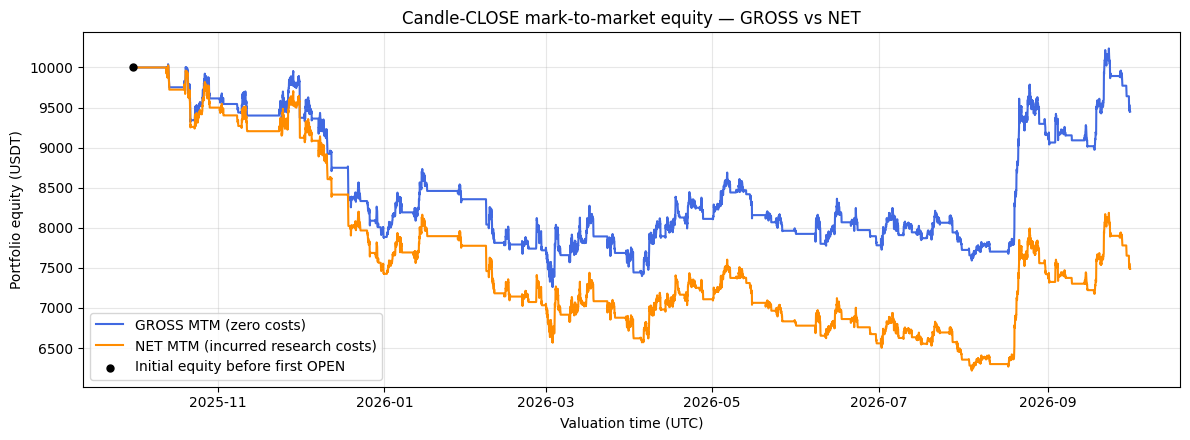

In [23]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(gross_equity_path["valuation_time"], gross_equity_path["equity"],
        label="GROSS MTM (zero costs)", color="royalblue")
ax.plot(net_equity_path["valuation_time"], net_equity_path["equity"],
        label="NET MTM (incurred research costs)", color="darkorange")
ax.scatter([gross_equity_path["valuation_time"].iloc[0]],
           [gross_equity_path["equity"].iloc[0]],
           color="black", s=25, zorder=4, label="Initial equity before first OPEN")
ax.set(title="Candle-CLOSE mark-to-market equity — GROSS vs NET",
       xlabel="Valuation time (UTC)", ylabel="Portfolio equity (USDT)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 24. Check equity references, representative exits, and preservation

These BTC numbers are **regression references only**, not sources for any
table or plot. Check initial-before-fill state and final OPEN trade 78 against
the helper outputs. Final position value equals equity because cash is zero.

Inspect the first, middle, and last CLOSED trades in each simulation. At their
exit OPEN, the strategy becomes flat; that candle's CLOSE equity must match
canonical `capital_after` / `net_capital_after`. Read those existing values
without rebuilding exit economics. Finally, confirm input and path preservation.


In [24]:
equity_columns = [
    "observation", "candle_timestamp", "valuation_time", "mark_price", "position",
    "active_trade_id", "cash", "quantity", "position_value", "unrealized_pnl", "equity",
]
assert len(candles) == 8_760
for label, equity_path, closed_results, capital_column, final_references in [
    ("GROSS", gross_equity_path, gross_closed, "capital_after",
     [0.1130341406801471, -189.62607440501543, 9451.485313939314]),
    ("NET", net_equity_path, net_closed, "net_capital_after",
     [0.08958523064731405, -154.10871530682684, 7490.776562851941]),
]:
    assert equity_path.columns.tolist() == equity_columns
    assert len(equity_path) == len(candles) + 1 == 8_761
    initial, final = equity_path.iloc[0], equity_path.iloc[-1]
    assert initial["position"] == 0
    assert pd.isna(initial["mark_price"]) and pd.isna(initial["candle_timestamp"])
    assert pd.isna(initial["active_trade_id"])
    assert initial["valuation_time"] == candles["timestamp"].iloc[0]
    np.testing.assert_allclose(initial[["cash", "equity"]].to_numpy(dtype=float), [10_000, 10_000])
    np.testing.assert_allclose(initial[["quantity", "position_value", "unrealized_pnl"]].to_numpy(dtype=float), [0, 0, 0])
    assert final["position"] == 1 and final["active_trade_id"] == 78
    assert final["cash"] == 0
    np.testing.assert_allclose(final["mark_price"], 83_616.2, rtol=1e-12)
    assert final["valuation_time"] == candles["timestamp"].iloc[-1] + candle_interval
    np.testing.assert_allclose(
        final[["quantity", "unrealized_pnl", "equity"]].to_numpy(dtype=float),
        final_references, rtol=1e-12, atol=1e-9,
    )
    np.testing.assert_allclose(final["position_value"], final["equity"], rtol=1e-12)
    representative_closed = closed_results.iloc[[0, len(closed_results) // 2, -1]]
    for trade in representative_closed.itertuples():
        exit_mark = equity_path.loc[equity_path["candle_timestamp"].eq(trade.exit_time)].iloc[0]
        assert exit_mark["position"] == 0
        np.testing.assert_allclose(exit_mark["equity"], getattr(trade, capital_column), rtol=1e-12)
    print(label, "representative exit reconciliation passed for trades", representative_closed["trade_id"].tolist())

np.testing.assert_allclose(realized_vs_marked["Last realized CLOSED capital"],
                           [9641.111388344, 7652.530163437], rtol=1e-10)
pd.testing.assert_series_equal(gross_equity_path["mark_price"], net_equity_path["mark_price"])
assert trades["status"].iloc[-1] == "OPEN" and trades["trade_id"].iloc[-1] == 78
assert pd.isna(trades["exit_time"].iloc[-1])
assert pd.isna(gross_results["capital_after"].iloc[-1])
assert pd.isna(net_results["net_capital_after"].iloc[-1])
pd.testing.assert_frame_equal(candles, candles_before_equity)
pd.testing.assert_frame_equal(gross_results, gross_before_equity)
pd.testing.assert_frame_equal(net_results, net_before_equity)
pd.testing.assert_frame_equal(gross_equity_path, gross_equity_before_display)
pd.testing.assert_frame_equal(net_equity_path, net_equity_before_display)
print("Equity references, still-OPEN state, and input/path preservation passed.")


GROSS representative exit reconciliation passed for trades [1, 39, 77]
NET representative exit reconciliation passed for trades [1, 39, 77]
Equity references, still-OPEN state, and input/path preservation passed.


## 25. TRADE DURATION AND EXPOSURE

Call the two existing Stage 5.8 helpers from `trading_lab.analytics.trade_time`
directly on **`trades`**, the canonical executed ledger. This ledger-based,
strategy-independent section follows [decision 005](../decisions/005_trade_duration_and_exposure.md).
The reusable module supplies all time calculations; the notebook only presents
its outputs and checks fixed-sample references. These are holding-time metrics,
not financial PnL metrics.

There is exactly **one TIME summary**, with no GROSS/NET split. Current costs
change prices, fees, quantities, PnL, and capital, but leave recorded entry/exit
fill times unchanged. Neither accounting output supplies time analytics.

**Exposure asks: "What percentage of the full observed market window was the
strategy actually holding a position?"** For this hourly sample, derive start
from the first loaded candle timestamp and end from the last timestamp plus one
hour. Candle timestamps label OPEN times, so adding the interval includes the
entire final candle. Do not infer the boundaries from trades.

The full denominator intentionally includes warm-up, time before the first
trade, flat periods between/after CLOSED trades, and the observed part of the
final OPEN trade. Exposure measures binary holding time under the current
single-position, non-overlapping ledger contract.

Display counts as integers, durations as hours, and exposure as a percentage;
formatting leaves the source values unchanged.

In [25]:
trades_before_time = trades.copy(deep=True)
observation_start = candles["timestamp"].iloc[0]
observation_end = candles["timestamp"].iloc[-1] + pd.Timedelta(hours=1)

trade_time_breakdown = calculate_trade_time_breakdown(
    trades, observation_start, observation_end,
)
trade_time_summary = summarize_trade_time_metrics(
    trades, observation_start, observation_end,
)
pd.testing.assert_frame_equal(trades, trades_before_time)
trade_time_breakdown_before_display = trade_time_breakdown.copy(deep=True)
trade_time_summary_before_display = trade_time_summary.copy(deep=True)

time_labels = {
    "closed_trade_count": "CLOSED trades",
    "open_trade_count": "OPEN trades",
    "average_closed_duration_hours": "Average CLOSED duration",
    "median_closed_duration_hours": "Median CLOSED duration",
    "minimum_closed_duration_hours": "Minimum CLOSED duration",
    "maximum_closed_duration_hours": "Maximum CLOSED duration",
    "total_closed_duration_hours": "Total CLOSED duration",
    "open_observed_duration_hours": "Final OPEN observed duration",
    "total_time_in_market_hours": "Total time in market",
    "observation_window_hours": "Full observation window",
    "exposure_ratio": "Exposure",
}
time_table = trade_time_summary.T.rename(index=time_labels)
time_table.index.name = "Ledger time metric"
print("Observation window [start, end):", observation_start, "→", observation_end)
display(time_table.style.format("{:,.4f} h", na_rep="—")
    .format("{:,.0f}", subset=pd.IndexSlice[list(time_labels.values())[:2], :])
    .format("{:.6%}", subset=pd.IndexSlice[[time_labels["exposure_ratio"]], :]))

Observation window [start, end): 2025-10-01 00:00:00+00:00 → 2026-10-01 00:00:00+00:00


,TIME
Ledger time metric,
CLOSED trades,77
OPEN trades,1
Average CLOSED duration,52.9610 h
Median CLOSED duration,34.0000 h
Minimum CLOSED duration,1.0000 h
Maximum CLOSED duration,226.0000 h
Total CLOSED duration,"4,078.0000 h"
Final OPEN observed duration,11.0000 h
Total time in market,"4,089.0000 h"


## 26. Read durations and inspect recorded trades

**CLOSED duration** is actual elapsed time from recorded entry fill to recorded
exit fill. It is not a candle count, signal-to-signal time, a signal-to-execution
delay, or rounded days. Comparing mean and median helps describe the distribution:
a higher mean in this sample reflects some relatively long holding periods,
without establishing strategy quality.

The compact preview shows the first and last three trades in their original
order. The longest-trades table sorts only a temporary CLOSED view of the
breakdown; it never sorts the canonical ledger or breakdown. A dash represents
a missing exit or undefined completed duration.

**The final OPEN trade has no completed duration:** `closed_duration_hours` stays
NaN. It is excluded from average, median, minimum, maximum, and total CLOSED
duration. Its already observed holding time still belongs in exposure through
`observation_end`: it was exposed during those hours even though it had not
completed. No exit is invented and the time helpers calculate no market
value; the separate MTM section supplies that valuation.

The same ledger-based analytics can later compare EMA, RSI, momentum, or ML
models that produce canonical executed trades. No strategy-specific duration
code is required.

In [26]:
time_preview = pd.concat([trade_time_breakdown.head(3), trade_time_breakdown.tail(3)])
time_display_formats = {
    "trade_id": "{:,.0f}",
    "entry_time": lambda value: value.strftime("%Y-%m-%d %H:%M %Z"),
    "exit_time": lambda value: value.strftime("%Y-%m-%d %H:%M %Z"),
    "closed_duration_hours": "{:,.2f} h",
    "observed_time_in_market_hours": "{:,.2f} h",
}
print("First three and last three trades — original ledger order:")
display(time_preview.style.format(time_display_formats, na_rep="—"))

closed_time_view = trade_time_breakdown.loc[trade_time_breakdown["status"].eq("CLOSED")]
longest_closed_trades = closed_time_view.sort_values(
    "closed_duration_hours", ascending=False, kind="stable",
).head(5)[["trade_id", "entry_time", "exit_time", "closed_duration_hours"]]
print("Five longest CLOSED trades — display view only:")
display(longest_closed_trades.style.format(
    {column: time_display_formats[column] for column in longest_closed_trades.columns},
    na_rep="—",
))

time_metrics = trade_time_summary.loc["TIME"]
first_closed_time = closed_time_view.iloc[0]
longest_closed_time = longest_closed_trades.iloc[0]
final_open_time = trade_time_breakdown.loc[trade_time_breakdown["status"].eq("OPEN")].iloc[0]
display(Markdown(
    f"**This BTC sample:** average CLOSED duration is "
    f"**{time_metrics['average_closed_duration_hours']:.4f} h**, median "
    f"**{time_metrics['median_closed_duration_hours']:.0f} h**, minimum "
    f"**{time_metrics['minimum_closed_duration_hours']:.0f} h**, and maximum "
    f"**{time_metrics['maximum_closed_duration_hours']:.0f} h**. The first CLOSED "
    f"trade lasted **{first_closed_time['closed_duration_hours']:.0f} h**; the "
    f"longest is trade **{int(longest_closed_time['trade_id'])}**, shown above.\n\n"
    f"The strategy held a position for **{time_metrics['total_time_in_market_hours']:,.0f} h** "
    f"of the full **{time_metrics['observation_window_hours']:,.0f} h** observed window: "
    f"exposure is **{time_metrics['exposure_ratio']:.2%}**. The reusable summary "
    f"reports **{time_metrics['total_closed_duration_hours']:,.0f} CLOSED hours** "
    f"and **{time_metrics['open_observed_duration_hours']:.0f} observed OPEN hours**.\n\n"
    f"Final OPEN trade **{int(final_open_time['trade_id'])}** entered at "
    f"**{final_open_time['entry_time']:%Y-%m-%d %H:%M %Z}** and contributes "
    f"**{final_open_time['observed_time_in_market_hours']:.0f} observed hours** "
    "through the sample end. Its completed duration is still **NaN**, with no "
    "exit or valuation in the TIME output. Its separate MTM value is shown above. "
    "These observations describe holding-time behavior, "
    "not profitability; higher or lower exposure is not inherently better."
))

First three and last three trades — original ledger order:


,trade_id,status,entry_time,exit_time,closed_duration_hours,observed_time_in_market_hours
0,1,CLOSED,2025-10-13 03:00 UTC,2025-10-14 06:00 UTC,27.00 h,27.00 h
1,2,CLOSED,2025-10-19 16:00 UTC,2025-10-21 10:00 UTC,42.00 h,42.00 h
2,3,CLOSED,2025-10-21 15:00 UTC,2025-10-22 04:00 UTC,13.00 h,13.00 h
75,76,CLOSED,2026-09-27 03:00 UTC,2026-09-28 03:00 UTC,24.00 h,24.00 h
76,77,CLOSED,2026-09-29 14:00 UTC,2026-09-29 16:00 UTC,2.00 h,2.00 h
77,78,OPEN,2026-09-30 13:00 UTC,—,—,11.00 h


Five longest CLOSED trades — display view only:


,trade_id,entry_time,exit_time,closed_duration_hours
67,68,2026-08-17 05:00 UTC,2026-08-26 15:00 UTC,226.00 h
66,67,2026-08-03 18:00 UTC,2026-08-10 16:00 UTC,166.00 h
40,41,2026-04-05 18:00 UTC,2026-04-12 07:00 UTC,157.00 h
44,45,2026-05-01 05:00 UTC,2026-05-07 15:00 UTC,154.00 h
74,75,2026-09-17 16:00 UTC,2026-09-23 21:00 UTC,149.00 h


**This BTC sample:** average CLOSED duration is **52.9610 h**, median **34 h**, minimum **1 h**, and maximum **226 h**. The first CLOSED trade lasted **27 h**; the longest is trade **68**, shown above.

The strategy held a position for **4,089 h** of the full **8,760 h** observed window: exposure is **46.68%**. The reusable summary reports **4,078 CLOSED hours** and **11 observed OPEN hours**.

Final OPEN trade **78** entered at **2026-09-30 13:00 UTC** and contributes **11 observed hours** through the sample end. Its completed duration is still **NaN**, with no exit or valuation in the TIME output. Its separate MTM value is shown above. These observations describe holding-time behavior, not profitability; higher or lower exposure is not inherently better.

## 27. Check TIME references and input preservation

These fixed BTC values are regression references only. Compare them with the
existing helper outputs; do not reproduce duration or exposure formulas here.
A mismatch stops execution for investigation. Check the exact TIME schema,
counts, elapsed hours, exposure, first/longest CLOSED trades, and the final
OPEN trade's missing completed duration and positive observed contribution.

Verify that calculation and display preserve the ledger and both time outputs.
The existing final raw-file hash check below remains in place.

In [27]:
time_references = {
    "closed_trade_count": 77,
    "open_trade_count": 1,
    "average_closed_duration_hours": 52.96103896103896,
    "median_closed_duration_hours": 34.0,
    "minimum_closed_duration_hours": 1.0,
    "maximum_closed_duration_hours": 226.0,
    "total_closed_duration_hours": 4078.0,
    "open_observed_duration_hours": 11.0,
    "total_time_in_market_hours": 4089.0,
    "observation_window_hours": 8760.0,
    "exposure_ratio": 0.46678082191780823,
}
assert trade_time_summary.index.tolist() == ["TIME"]
assert trade_time_summary.columns.tolist() == list(time_references)
assert trade_time_summary.dtypes.astype(str).tolist() == ["int64"] * 2 + ["float64"] * 9
assert tuple(trade_time_summary.loc["TIME", ["closed_trade_count", "open_trade_count"]]) == (77, 1)
np.testing.assert_allclose(
    trade_time_summary.loc["TIME"].to_numpy(dtype="float64"),
    list(time_references.values()), rtol=1e-12, atol=1e-12,
)
np.testing.assert_allclose(first_closed_time["closed_duration_hours"], 27.0)
assert int(longest_closed_time["trade_id"]) == 68
np.testing.assert_allclose(longest_closed_time["closed_duration_hours"], 226.0)
assert final_open_time["status"] == "OPEN"
assert int(final_open_time["trade_id"]) == 78
assert final_open_time["entry_time"] == pd.Timestamp("2026-09-30 13:00", tz="UTC")
assert pd.isna(final_open_time["exit_time"])
assert pd.isna(final_open_time["closed_duration_hours"])
np.testing.assert_allclose(final_open_time["observed_time_in_market_hours"], 11.0)
assert 0 < time_metrics["exposure_ratio"] < 1

source_time_columns = ["trade_id", "status", "entry_time", "exit_time"]
pd.testing.assert_frame_equal(trade_time_breakdown[source_time_columns], trades[source_time_columns])
pd.testing.assert_frame_equal(trades, trades_before_time)
pd.testing.assert_frame_equal(trade_time_breakdown, trade_time_breakdown_before_display)
pd.testing.assert_frame_equal(trade_time_summary, trade_time_summary_before_display)
print("All TIME references, OPEN observed contribution, and ledger/output preservation passed.")

All TIME references, OPEN observed contribution, and ledger/output preservation passed.


## 28. Inspect transaction costs

Use **CLOSED trades only**. Sum/average the fee columns already produced by Stage
4.7. Modelled slippage impact is `gross_pnl - price_adjusted_pnl`, using that
same cost-aware simulation's quantity; it is positive when adverse prices reduce PnL.

The final OPEN entry fee is excluded from these round-trip summaries and shown
separately below. These descriptive calculations stay in the notebook. Fees plus
slippage on this sizing path do not equal the final-capital gap between the two
simulations, because their later quantities differ.

In [28]:
modeled_slippage_impact = net_closed["gross_pnl"] - net_closed["price_adjusted_pnl"]
entry_fee_sum = float(net_closed["entry_fee"].sum())
exit_fee_sum = float(net_closed["exit_fee"].sum())
total_fee_sum = float(net_closed["total_fees"].sum())
average_total_fee = float(net_closed["total_fees"].mean())
total_slippage_impact = float(modeled_slippage_impact.sum())
average_slippage_impact = float(modeled_slippage_impact.mean())

cost_summary = pd.Series({
    "Sum of entry fees": entry_fee_sum,
    "Sum of exit fees": exit_fee_sum,
    "Sum of total fees": total_fee_sum,
    "Average total fee per CLOSED trade": average_total_fee,
    "Total modeled slippage impact": total_slippage_impact,
    "Average modeled slippage impact per CLOSED trade": average_slippage_impact,
}, name="USDT — CLOSED trades only")
display(cost_summary.to_frame().style.format("{:,.9f}"))

,USDT — CLOSED trades only
Sum of entry fees,577.318661158
Sum of exit fees,576.124634617
Sum of total fees,"1,153.443295774"
Average total fee per CLOSED trade,14.979783062
Total modeled slippage impact,576.721493561
Average modeled slippage impact per CLOSED trade,7.489889527


## 29. Visualize accumulated modeled costs

Show cumulative fees and cumulative fees plus modeled slippage on the Stage 4.7
quantity path. Their separation shows the accumulated slippage component.
These lines are descriptive sums across CLOSED trades, not another execution
model or the gross/net final-capital gap. This complements the capital chart.

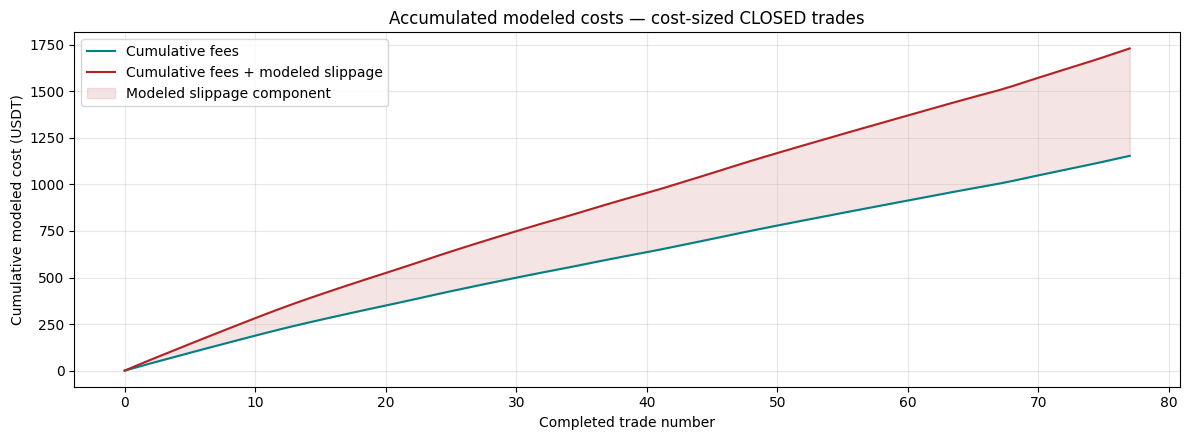

In [29]:
cumulative_fees = net_closed["total_fees"].cumsum()
cumulative_direct_costs = (net_closed["total_fees"] + modeled_slippage_impact).cumsum()
cost_trade_numbers = [0, *net_closed["trade_id"].tolist()]
fee_points = [0.0, *cumulative_fees.tolist()]
direct_cost_points = [0.0, *cumulative_direct_costs.tolist()]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(cost_trade_numbers, fee_points, label="Cumulative fees", color="teal")
ax.plot(cost_trade_numbers, direct_cost_points, label="Cumulative fees + modeled slippage", color="firebrick")
ax.fill_between(cost_trade_numbers, fee_points, direct_cost_points, color="firebrick", alpha=0.12, label="Modeled slippage component")
ax.set(title="Accumulated modeled costs — cost-sized CLOSED trades", xlabel="Completed trade number", ylabel="Cumulative modeled cost (USDT)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 30. First trade walkthrough

Read all values directly from the existing outputs. Adverse slippage increases
the effective LONG entry price and reduces the effective exit price. Self-financing
sizing leaves room for the entry fee; the exit fee reduces sale proceeds further.
Therefore net PnL is below the recorded-price gross PnL for this quantity.

The last two rows show the net return and net capital after closing. The separate
zero-cost gross PnL is shown for reference; it uses a different quantity.
Prices, fees, PnL, and capital use USDT; quantity uses BTC; return is decimal.

In [30]:
first_net_trade = net_closed.iloc[0]
first_trade_fields = [
    "entry_price", "effective_entry_price", "exit_price", "effective_exit_price",
    "quantity", "entry_fee", "exit_fee", "total_fees", "gross_pnl",
    "price_adjusted_pnl", "net_pnl", "net_trade_return", "net_capital_after",
]
print("First executed entry:", first_net_trade["entry_time"])
print("First executed exit:", first_net_trade["exit_time"])
display(first_net_trade[first_trade_fields].rename("Stage 4.7 value").to_frame().style.format("{:,.12f}"))
print(f"Separate Stage 4.6 first-trade gross PnL: {gross_closed['gross_pnl'].iloc[0]:,.9f} USDT")

First executed entry: 2025-10-13 03:00:00+00:00
First executed exit: 2025-10-14 06:00:00+00:00


,Stage 4.7 value
entry_price,"115,332.300000000003"
effective_entry_price,"115,389.966149999993"
exit_price,"112,482.000000000000"
effective_exit_price,"112,425.759000000005"
quantity,0.086576071762
entry_fee,9.990009990010
exit_fee,9.733380579074
total_fees,19.723390569084
gross_pnl,-246.767777343052
price_adjusted_pnl,-256.629410935649


Separate Stage 4.6 first-trade gross PnL: -247.138052393 USDT


## 31. Inspect the final OPEN trade

Trade **78 remains OPEN**: it has an executed entry but no recorded exit. The
accounting table still has missing exit fields, realized return/PnL, capital
after, and round-trip total fees. Its known NET entry fee is already paid.

The separate Stage 5.11 paths now mark both simulations at the final candle
CLOSE. The state table below reads their final rows directly: position 1,
active trade 78, zero cash, and a raw market CLOSE of 83,616.2 USDT. Quantity,
price-based unrealized PnL, position value, and equity come from those helpers.
This is a valuation, not a sale or realized ending capital. NET marks charge
no hypothetical future exit fee/slippage and do not subtract entry fee again.

The Stage 5.2 summary still excludes this trade from all 16 CLOSED metrics,
and realized-capital drawdown excludes it. TIME observes its 11 holding hours
but leaves completed duration NaN. These separate analytics stay unchanged.


In [31]:
open_results = net_results.loc[net_results["status"].eq("OPEN")]
open_columns = [
    "trade_id", "entry_time", "entry_price", "effective_entry_price",
    "capital_before", "quantity", "entry_fee", "status",
]
display(open_results[open_columns].style.format({
    "entry_price": "{:,.6f}", "effective_entry_price": "{:,.6f}",
    "capital_before": "{:,.9f}", "quantity": "{:.12f}", "entry_fee": "{:,.9f}",
}))
missing_open_fields = [
    "exit_time", "exit_price", "effective_exit_price", "exit_notional", "exit_fee",
    "total_fees", "gross_pnl", "price_adjusted_pnl", "net_pnl",
    "net_trade_return", "net_capital_after",
]
assert open_results[missing_open_fields].isna().all().all()
np.testing.assert_allclose(open_results["capital_before"], final_net_capital)
assert open_results["trade_id"].tolist() == [78]
assert open_results["status"].tolist() == ["OPEN"]
print("Trade 78 remains OPEN: exit and realized results are missing; MTM values it separately.")

final_mark_fields = [
    "valuation_time", "mark_price", "position", "active_trade_id", "cash",
    "quantity", "unrealized_pnl", "position_value", "equity",
]
final_open_marks = pd.DataFrame({
    "GROSS": final_gross_mark[final_mark_fields],
    "NET": final_net_mark[final_mark_fields],
})
final_open_marks.index.name = "Final OPEN mark — valuation, not liquidation"
display(final_open_marks.style
    .format("{:,.6f} USDT", subset=pd.IndexSlice[
        ["mark_price", "cash", "unrealized_pnl", "position_value", "equity"], :])
    .format("{:.12f} BTC", subset=pd.IndexSlice[["quantity"], :])
    .format("{:,.0f}", subset=pd.IndexSlice[["position", "active_trade_id"], :])
    .format(lambda value: value.strftime("%Y-%m-%d %H:%M %Z"),
            subset=pd.IndexSlice[["valuation_time"], :]))

,trade_id,entry_time,entry_price,effective_entry_price,capital_before,quantity,entry_fee,status
77,78,2026-09-30 13:00:00+00:00,"85,293.800000","85,336.446900","7,652.530163437",0.089585230647,7.644885278,OPEN


Trade 78 remains OPEN: exit and realized results are missing; MTM values it separately.


,GROSS,NET
"Final OPEN mark — valuation, not liquidation",,
valuation_time,2026-10-01 00:00 UTC,2026-10-01 00:00 UTC
mark_price,"83,616.200000 USDT","83,616.200000 USDT"
position,1,1
active_trade_id,78,78
cash,0.000000 USDT,0.000000 USDT
quantity,0.113034140680 BTC,0.089585230647 BTC
unrealized_pnl,-189.626074 USDT,-154.108715 USDT
position_value,"9,451.485314 USDT","7,490.776563 USDT"
equity,"9,451.485314 USDT","7,490.776563 USDT"


## 32. Check preservation and the zero-cost regression

Confirm that both accounting outputs preserve the six ledger columns and that
all inputs remain unchanged in memory. The raw-file hash must also match.
Running the cost helper with zero rates should agree economically with Stage
4.6; floating-point tolerance handles equivalent arithmetic expressions.

Earlier assertions checked the fixed snapshot's counts and final capitals.
They are validation/reference expectations only; all displayed results came
from the loaded data and reusable functions. A mismatch stops execution for investigation.

In [32]:
pd.testing.assert_frame_equal(candles, candles_before)
pd.testing.assert_frame_equal(pipeline_df, pipeline_before)
pd.testing.assert_frame_equal(trades, trades_before)
pd.testing.assert_frame_equal(gross_results, gross_before_equity)
pd.testing.assert_frame_equal(net_results, net_before_equity)
pd.testing.assert_frame_equal(gross_results[trades.columns], trades)
pd.testing.assert_frame_equal(net_results[trades.columns], trades)
assert hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before

zero_cost_results = calculate_trade_results_with_costs(
    trades, initial_capital=INITIAL_CAPITAL, fee_rate=0.0, slippage_rate=0.0,
)
for gross_column, net_column in [
    ("quantity", "quantity"), ("trade_return", "net_trade_return"),
    ("gross_pnl", "gross_pnl"), ("gross_pnl", "net_pnl"), ("capital_after", "net_capital_after"),
]:
    np.testing.assert_allclose(
        gross_results[gross_column], zero_cost_results[net_column],
        rtol=1e-12, atol=1e-10, equal_nan=True,
    )
print("Snapshot references, zero-cost equivalence, and input/raw preservation passed.")

Snapshot references, zero-cost equivalence, and input/raw preservation passed.


## 33. Conclusions and limitations

The summary below is generated from this run, rather than hardcoded financial or time
outputs. It describes this specific historical BTC sample under the current assumptions.

In [33]:
display(Markdown(
    f"The **{len(candles):,}-candle** snapshot produced **{entry_count} LONG_ENTRY** "
    f"and **{exit_count} LONG_EXIT** signals, forming **{closed_count} CLOSED** "
    f"trades and **{open_count} OPEN** trade. From **{INITIAL_CAPITAL:,.2f} USDT**, "
    f"final gross realized capital is **{final_gross_capital:,.6f} USDT** "
    f"(**{gross_realized_return:.6%}**), while final net realized capital is "
    f"**{final_net_capital:,.6f} USDT** (**{net_realized_return:.6%}**). "
    f"The gap is **{capital_difference:,.6f} USDT**, including fees, slippage, "
    "and their compounded sizing impact. These realized values are before the final OPEN entry.\n\n"
    f"The candle-CLOSE MTM paths each contain **{len(gross_equity_path):,} observations**, "
    "including the initial point. Final trade "
    f"**{int(final_gross_mark['active_trade_id'])} remains OPEN**, now marked at the "
    f"final CLOSE of **{final_gross_mark['mark_price']:,.2f} USDT**. "
    f"GROSS marked equity is **{final_gross_mark['equity']:,.2f} USDT**, and NET is "
    f"**{final_net_mark['equity']:,.2f} USDT**. These differ from CLOSED realized "
    "capital and are not realized ending capital. MTM observes within-trade "
    "candle-CLOSE movement but still misses intrabar/tick lows.\n\n"
    f"Maximum realized-capital drawdown is "
    f"**{gross_drawdown_summary.loc['GROSS', 'max_realized_drawdown']:.2%}** gross "
    f"and **{net_drawdown_summary.loc['NET', 'max_realized_drawdown']:.2%}** net. "
    "These are CLOSED-trade realized-capital observations, not mark-to-market "
    "portfolio drawdowns; losses while trades are open can make full portfolio "
    "drawdown worse.\n\n"
    f"Average CLOSED duration is **{time_metrics['average_closed_duration_hours']:.2f} h**, "
    f"median **{time_metrics['median_closed_duration_hours']:.0f} h**, and longest "
    f"**{time_metrics['maximum_closed_duration_hours']:.0f} h**. Exposure is "
    f"**{time_metrics['exposure_ratio']:.2%}** of the full candle window, including "
    f"**{final_open_time['observed_time_in_market_hours']:.0f} observed hours** "
    "from the final OPEN trade. CLOSED duration statistics exclude that "
    "unfinished trade. This describes holding-time behavior, not profitability; "
    "neither higher nor lower exposure is inherently better."
))

The **8,760-candle** snapshot produced **78 LONG_ENTRY** and **77 LONG_EXIT** signals, forming **77 CLOSED** trades and **1 OPEN** trade. From **10,000.00 USDT**, final gross realized capital is **9,641.111388 USDT** (**-3.588886%**), while final net realized capital is **7,652.530163 USDT** (**-23.474698%**). The gap is **1,988.581225 USDT**, including fees, slippage, and their compounded sizing impact. These realized values are before the final OPEN entry.

The candle-CLOSE MTM paths each contain **8,761 observations**, including the initial point. Final trade **78 remains OPEN**, now marked at the final CLOSE of **83,616.20 USDT**. GROSS marked equity is **9,451.49 USDT**, and NET is **7,490.78 USDT**. These differ from CLOSED realized capital and are not realized ending capital. MTM observes within-trade candle-CLOSE movement but still misses intrabar/tick lows.

Maximum realized-capital drawdown is **-26.72%** gross and **-37.19%** net. These are CLOSED-trade realized-capital observations, not mark-to-market portfolio drawdowns; losses while trades are open can make full portfolio drawdown worse.

Average CLOSED duration is **52.96 h**, median **34 h**, and longest **226 h**. Exposure is **46.68%** of the full candle window, including **11 observed hours** from the final OPEN trade. CLOSED duration statistics exclude that unfinished trade. This describes holding-time behavior, not profitability; neither higher nor lower exposure is inherently better.

This result **does not prove that the strategy is good or bad in general**.
It describes one historical sample under a specific next-open fill and cost model.

- EMA parameters were not optimized here; no other combinations were searched.
- No out-of-sample test or walk-forward validation exists yet.
- Costs are fixed modeled research assumptions, not verified exchange fees or actual fills.
- The model uses no leverage and allocates 100% of capital per trade, including the entry fee.
- Final trade 78 remains OPEN. It is excluded from all 16 CLOSED performance
  metrics and realized-capital drawdown, but is valued by the separate MTM paths.
  Its observed holding time contributes to exposure; completed duration stays NaN.
- Arithmetic average trade return differs from compounded strategy return;
  sample expectancy is historical realized PnL, not a forecast.
- REALIZED-CAPITAL drawdown sees only initial capital and capital after CLOSED
  trades. The separate candle-CLOSE MTM path observes held value during trades.
- Candle-CLOSE MTM still does **not** capture the exact path inside each hourly
  candle. Future drawdown from these equity paths can reveal within-trade declines
  but can still understate intrabar/tick risk; it is not continuous-time drawdown.
- Marking is valuation, not liquidation. NET includes costs already incurred;
  it adds no hypothetical future exit fee or sell slippage at a CLOSE.
- Duration and binary exposure describe holding-time behavior under the current
  non-overlapping, single-position ledger contract, not profitability or
  position-size/leverage-weighted risk.
- No portfolio drawdown, drawdown duration/recovery, Sharpe, Sortino, benchmarks,
  or annualization is calculated here.

Stage 5.12 presents the two unchanged Stage 5.11 equity helpers after realized
drawdown and before TIME. Compact path previews, a realized-versus-marked table,
one time-axis equity plot, final OPEN marks, and regression/preservation checks
use their outputs directly. The existing metrics, drawdown, TIME, and cost
sections remain, with all three previous plots plus exactly one MTM plot: **four
plots total**. No reusable financial/time formulas are duplicated, and no dataset
or separate report is exported.

Recommended next: **Stage 5.13 — Candle-Close Portfolio Drawdown Contract**,
defining drawdown from the new `equity` paths. Stage 5.13 has not started and
requires approval.
